# Comparing Almost Linear time Union Find Decoder with Mininmum Weight Perfect Matching

This jupyter notebook combined with uf_decoder.py compares pymatchings MWPM decoder with a custom built nieve union find decoder.

## Investigatings pymatchings detector graph

From stims detection events, a graph needs to be created representing how stabalisers are linked in order to start decoding. The setup required to write the union find algorithm is slightly different to pymatchings MWPM however extrapollating from pymatchings graph makes it considerablly easier than building the graph from scratch via stims detector error model. Pymatchings graph is visualsied below, where nodes represents staibaisers and edges represents data qubits.

In [1]:
import stim
from pymatching import Matching
from matplotlib import pyplot as plt
import networkx

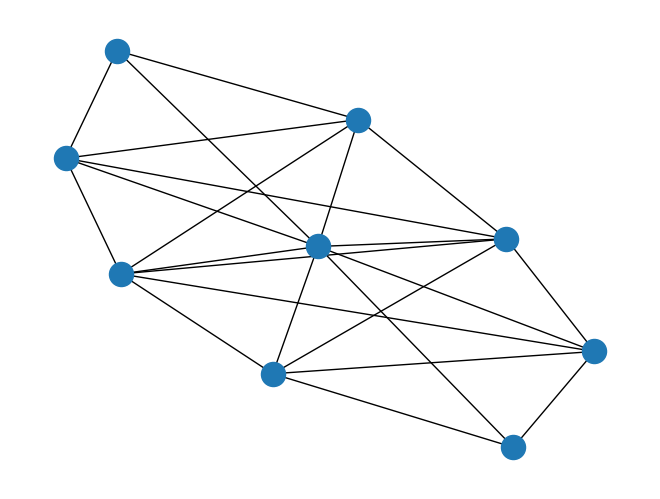

In [2]:
p = 0.003
circuit_initial = stim.Circuit.generated("surface_code:rotated_memory_x", 
                                        distance=3, 
                                        rounds = 1,
                                        after_clifford_depolarization=p,
                                        before_round_data_depolarization=0,
                                        before_measure_flip_probability=0)


model = circuit_initial.detector_error_model(decompose_errors=True)

matching = Matching.from_detector_error_model(model)
graph = matching.to_networkx()

networkx.draw(graph)
plt.savefig("graph.png", dpi=300)


## Monte-Carlo benchmark: UF+peeling vs PyMatching MWPM

As with the previous project, investigating repetition codes, the same techniques will be applied below, with the addition of comparing decoding times. 

### Imports and output folder
Bring in the sampling/decoding tools and the `UnionFindDecoder` from `uf_decoder.py`, then create
the `figures/` folder the plots are written to.

In [3]:
import time
from pathlib import Path

import numpy as np
import stim
from pymatching import Matching
import matplotlib.pyplot as plt

from uf_decoder import UnionFindDecoder, build_uf_graph, lit_vertices

FIG_DIR = Path("figures")
FIG_DIR.mkdir(exist_ok=True)

### Building one benchmark point
`build_bundle` generates a stim circuit for one `(code, distance, p)`, then builds the matching
graph, the MWPM decoder, UF decoder and a detector sampler 

In [4]:
def build_bundle(code_task, distance, p, rounds=1):
    """Build everything needed to benchmark one (code, distance, p) point."""
    circuit = stim.Circuit.generated(
        code_task, distance=distance, rounds=rounds,
        after_clifford_depolarization=p, before_measure_flip_probability=p,
    )
    dem = circuit.detector_error_model(decompose_errors=True)
    matching = Matching.from_detector_error_model(dem)
    
    adj, edge_faults, boundary = build_uf_graph(matching.to_networkx())
    uf = UnionFindDecoder(adj, edge_faults, boundary,
                          num_observables=matching.num_fault_ids)
    return {
        "code_task": code_task, "distance": distance, "p": p,
        "circuit": circuit, "matching": matching, "uf": uf,
        "sampler": circuit.compile_detector_sampler(),
        "num_detectors": circuit.num_detectors,
    }

### Figure 1 — decode time vs code size
To investigate code timing the code the decoders are run over increasing code distances. As the pymatching decoding algorithm is written in c++ it is much faster than the custonm python UF decoder, however when running over multipe code distances, a trend is shown. On a log-log pot, these are inear, and the smaller gradient shows wich decoder is faster as the code distance continues to increase. As seen below, the Naieve version of UF decoder will better upscale compared to MWPM

In [ ]:

def run_timing(bundle, shots):
    """Amortised per-shot decode time (seconds) for each decoder."""
    detection_events, _ = bundle["sampler"].sample(shots, separate_observables=True)

    uf = bundle["uf"]
    t0 = time.perf_counter()
    for row in detection_events:
        uf.decode(row)
    uf_t = (time.perf_counter() - t0) / shots

    matching = bundle["matching"]
    t0 = time.perf_counter()
    matching.decode_batch(detection_events)
    mwpm_t = (time.perf_counter() - t0) / shots
    return {"uf_time": uf_t, "mwpm_time": mwpm_t}

def sweep_timing(code_task, distances, p, shots):
    """Per-shot decode time vs distance/size."""
    n, uf_t, mwpm_t = [], [], []
    for d in distances:
        bundle = build_bundle(code_task, d, p)
        r = run_timing(bundle, shots)
        n.append(bundle["num_detectors"])
        uf_t.append(r["uf_time"])
        mwpm_t.append(r["mwpm_time"])
    return {"distances": np.array(distances), "num_detectors": np.array(n),
            "uf_time": np.array(uf_t), "mwpm_time": np.array(mwpm_t)}


def _powerlaw_exponent(n, t):
    """Fit log t = log a + b log n; return (exponent b, prefactor a)."""
    b, log_a = np.polyfit(np.log(n), np.log(t), 1)
    return b, np.exp(log_a)

def plot_time_vs_size(timing, path):
    """Log-log per-shot decode time vs detector count, with power-law fits."""
    n = timing["num_detectors"]
    fig, ax = plt.subplots(figsize=(6, 4.5))
    exponents = {}
    for key, label, style in [("uf_time", "UF+peeling", "o-"),
                              ("mwpm_time", "MWPM (PyMatching)", "s--")]:
        t = timing[key]
        b, a = _powerlaw_exponent(n, t)
        exponents[key] = b
        ax.plot(n, t, style, label=f"{label}  (b={b:.2f})")
        xs = np.linspace(n.min(), n.max(), 100)
        ax.plot(xs, a * xs ** b, ":", color="grey", linewidth=1)
    ax.set_xscale("log"); ax.set_yscale("log")
    ax.set_xlabel("number of detectors  n")
    ax.set_ylabel("per-shot decode time  (s)")
    ax.set_title("Decode time vs code size")
    ax.grid(True, which="both", alpha=0.3); ax.legend()
    fig.tight_layout(); fig.savefig(path, dpi=300)
    return exponents


timing = sweep_timing("surface_code:rotated_memory_x", [3, 5, 7, 9, 11, 13, 15, 17], p=0.01, shots=50000)
exponents = plot_time_vs_size(timing, FIG_DIR / "time_vs_size.png")
print("scaling exponents b:", {k: round(v, 2) for k, v in exponents.items()})

KeyboardInterrupt: 

### Investigating logical vs physical error rate (+ accuracy gap)
Plots logical error rate aginst physical error rate, to see how the accuracy compares for UF and MWPM


mean UF-vs-MWPM agreement: {3: 0.9099, 5: 0.8299, 7: 0.7865}


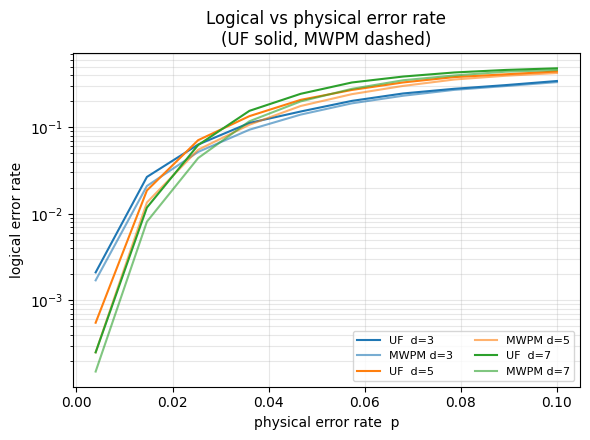

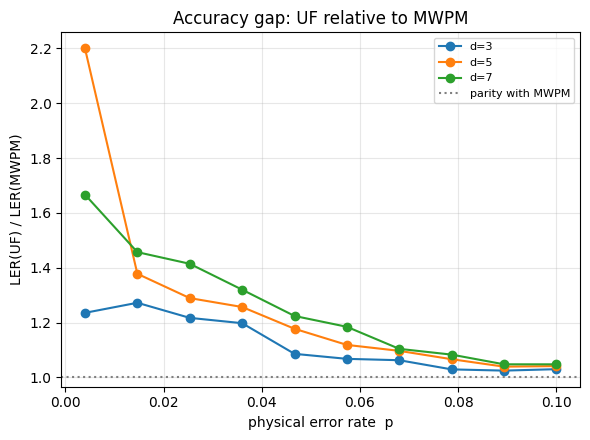

In [6]:
def _logical_errors(pred, observable_flips):
    """Count shots where the predicted flips differ from the truth."""
    return int(np.count_nonzero(np.any(pred != observable_flips, axis=1)))


def run_ler(bundle, shots):
    """Logical error rate + agreement for both decoders on `shots` samples."""
    detection_events, observable_flips = bundle["sampler"].sample(shots, separate_observables=True)
    observable_flips = observable_flips.astype(np.uint8)

    uf = bundle["uf"]
    uf_pred = np.array([uf.decode(row) for row in detection_events], dtype=np.uint8)
    mwpm_pred = bundle["matching"].decode_batch(detection_events).astype(np.uint8)

    uf_err = _logical_errors(uf_pred, observable_flips)
    mwpm_err = _logical_errors(mwpm_pred, observable_flips)
    agreement = float(np.mean(np.all(uf_pred == mwpm_pred, axis=1)))

    def rate_and_err(n_err):
        ler = n_err / shots
        return ler  
    uf_ler  = rate_and_err(uf_err)
    mwpm_ler  = rate_and_err(mwpm_err)
    return {"shots": shots, "uf_ler": uf_ler,
            "mwpm_ler": mwpm_ler,  "agreement": agreement}

def sweep_ler(code_task, distances, ps, shots):
    """Logical error rate vs p, one entry per distance."""
    ps = np.asarray(ps, dtype=float)
    out = {"ps": ps, "distances": list(distances), "by_distance": {}}
    for d in distances:
        uf_ler, mwpm_ler, agree = [], [], []
        for p in ps:
            r = run_ler(build_bundle(code_task, d, float(p)), shots)
            uf_ler.append(r["uf_ler"]); 
            mwpm_ler.append(r["mwpm_ler"]); 
            agree.append(r["agreement"])
        out["by_distance"][d] = {
            "uf_ler": np.array(uf_ler), 
            "mwpm_ler": np.array(mwpm_ler), 
            "agreement": np.array(agree)}
    return out

def plot_ler_vs_p(ler, path):
    """LER vs p for several distances; UF solid, MWPM dashed. Crossing ~ threshold."""
    ps = ler["ps"]
    fig, ax = plt.subplots(figsize=(6, 4.5))
    for i, d in enumerate(ler["distances"]):
        c = f"C{i}"                       # default matplotlib colour cycle
        r = ler["by_distance"][d]
        ax.plot(ps, r["uf_ler"],  color=c,
                    label=f"UF  d={d}")
        ax.plot(ps, r["mwpm_ler"], color=c,
                    alpha=0.6, label=f"MWPM d={d}")
    ax.set_yscale("log")
    ax.set_xlabel("physical error rate  p")
    ax.set_ylabel("logical error rate")
    ax.set_title("Logical vs physical error rate\n(UF solid, MWPM dashed)")
    ax.grid(True, which="both", alpha=0.3); ax.legend(fontsize=8, ncol=2)
    fig.tight_layout(); fig.savefig(path, dpi=300)




def plot_accuracy_gap(ler, path):
    """Ratio uf_ler/mwpm_ler vs p per distance -- accuracy traded for speed."""
    ps = ler["ps"]
    fig, ax = plt.subplots(figsize=(6, 4.5))
    for d in ler["distances"]:
        r = ler["by_distance"][d]
        with np.errstate(divide="ignore", invalid="ignore"):
            ratio = np.where(r["mwpm_ler"] > 0, r["uf_ler"] / r["mwpm_ler"], np.nan)
        ax.plot(ps, ratio, "o-", label=f"d={d}")
    ax.axhline(1.0, color="grey", linestyle=":", label="parity with MWPM")
    ax.set_xlabel("physical error rate  p")
    ax.set_ylabel("LER(UF) / LER(MWPM)")
    ax.set_title("Accuracy gap: UF relative to MWPM")
    ax.grid(True, alpha=0.3); ax.legend(fontsize=8)
    fig.tight_layout(); fig.savefig(path, dpi=300)


ps = np.linspace(0.004, 0.1, 10)
ler_x = sweep_ler("surface_code:rotated_memory_x", [3, 5, 7], ps, shots=20000)
plot_ler_vs_p(ler_x, FIG_DIR / "ler_vs_p.png")
plot_accuracy_gap(ler_x, FIG_DIR / "accuracy_gap.png")
print("mean UF-vs-MWPM agreement:",
      {d: round(float(r["agreement"].mean()), 4) for d, r in ler_x["by_distance"].items()})

### Figure 3 — X vs Z decoding (CSS symmetry)
As for this notebook we are using surface codes instead of repetition codes which are a form of quantum topological code that is intuitive for understanding decoding graphs, it felt worth checking the surface codes error correcetions for x and z, just to ensure they are symetricall and both work for the UF decoder. 

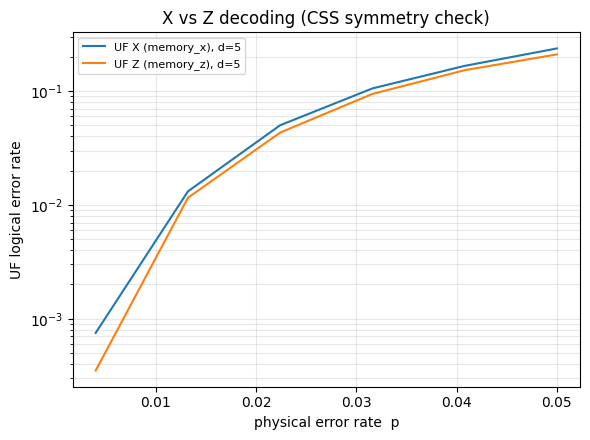

In [ ]:
def plot_xz_symmetry(ler_x, ler_z, path):
    """Overlay LER-vs-p for memory_x vs memory_z to show CSS symmetry."""
    ps = ler_x["ps"]
    fig, ax = plt.subplots(figsize=(6, 4.5))
    for ler, basis, marker in [(ler_x, "X (memory_x)", "o"),
                               (ler_z, "Z (memory_z)", "^")]:
        for d in ler["distances"]:
            r = ler["by_distance"][d]
            ax.plot(ps, r["uf_ler"], 
                         label=f"UF {basis}, d={d}")
    ax.set_yscale("log")
    ax.set_xlabel("physical error rate  p")
    ax.set_ylabel("UF logical error rate")
    ax.set_title("X vs Z decoding (CSS symmetry check)")
    ax.grid(True, which="both", alpha=0.3); ax.legend(fontsize=8)
    fig.tight_layout(); fig.savefig(path, dpi=300)


ler_x5 = sweep_ler("surface_code:rotated_memory_x", [5], ps, shots=20000)
ler_z5 = sweep_ler("surface_code:rotated_memory_z", [5], ps, shots=20000)
plot_xz_symmetry(ler_x5, ler_z5, FIG_DIR / "xz_symmetry.png")

## Is Union-Find worth it? — extrapolating distance & decode-time to a target fidelity

The plots above compare the two decoders only at small, accessible distances. To actually decide whether the almost-linear-time UF decoder is *worth* its accuracy penalty, we extrapolate both to a target logical error rate of `1e-12`

distance for 1e-12:       {'uf': 64.9, 'mwpm': 58.8}
time-scaling exponent b:  {'uf': 2.2, 'mwpm': 2.59}
decode time to reach 1e-12 (T0=1 at d=3):  UF=869  MWPM=2229  ->  UF wins (2.6x)
absolute d=3 handicap: pure-Python UF is 218x slower than C++ MWPM (normalised away above)


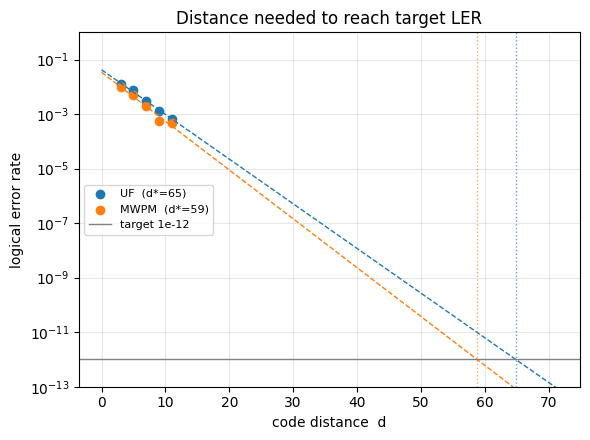

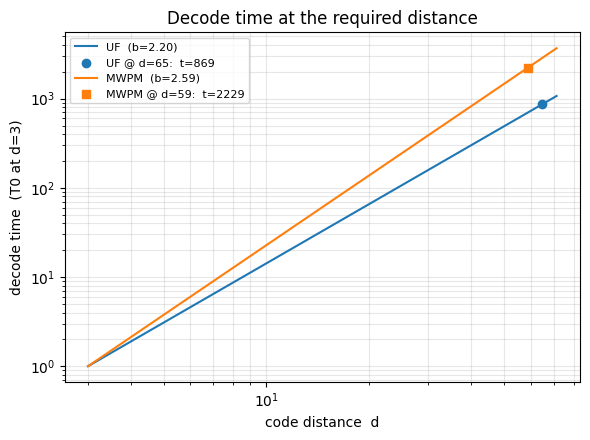

In [ ]:
def _extrapolate_distance(distances, lers, target):
    """Extrapolates distance forwards using linear log fit"""
    distances, lers = np.asarray(distances, float), np.asarray(lers, float)
    keep = lers > 0
    slope, intercept = np.polyfit(distances[keep], np.log(lers[keep]), 1)
    return slope, intercept, (np.log(target) - intercept) / slope


def sweep_scaling(code_task, distances, p, uf_shots, mwpm_shots):
    """Per-shot decode time vs distance. gradient of time against shots is recorded """
    uf_t, mwpm_t = [], []
    for d in distances:
        bundle = build_bundle(code_task, d, p)
        detection_events, _ = bundle["sampler"].sample(mwpm_shots, separate_observables=True)
        t0 = time.perf_counter()
        bundle["matching"].decode_batch(detection_events)
        mwpm_t.append((time.perf_counter() - t0) / mwpm_shots)
        t0 = time.perf_counter()
        for row in detection_events[:uf_shots]:
            bundle["uf"].decode(row)
        uf_t.append((time.perf_counter() - t0) / uf_shots)
    return {"distances": np.array(distances, float),
            "uf_time": np.array(uf_t), "mwpm_time": np.array(mwpm_t)}


def plot_distance_extrapolation(ler, target, path):
    """LER vs distance at fixed p with a log-linear fit projected to target; returns distance per decoder."""
    ds = np.array(ler["distances"], float)
    fits = {}
    for key, dec in [("uf_ler", "uf"), ("mwpm_ler", "mwpm")]:
        lers = np.array([ler["by_distance"][d][key][0] for d in ler["distances"]])
        fits[dec] = (_extrapolate_distance(ds, lers, target), lers)
    grid = np.linspace(0, max(f[0][2] for f in fits.values()) * 1.1, 200)

    fig, ax = plt.subplots(figsize=(6, 4.5))
    for dec, c in [("uf", "C0"), ("mwpm", "C1")]:
        (slope, intercept, d_star), lers = fits[dec]
        ax.scatter(ds, lers, color=c, label=f"{dec.upper()}  (d*={d_star:.0f})")
        ax.plot(grid, np.exp(intercept + slope * grid), "--", color=c, linewidth=1)
        ax.axvline(d_star, color=c, linestyle=":", linewidth=1, alpha=0.7)
    ax.axhline(target, color="grey", linewidth=1, label=f"target {target:.0e}")
    ax.set_yscale("log"); ax.set_ylim(1e-13, 1)
    ax.set_xlabel("code distance  d")
    ax.set_ylabel("logical error rate")
    ax.set_title("Distance needed to reach target LER")
    ax.grid(True, which="both", alpha=0.3); ax.legend(fontsize=8)
    fig.tight_layout(); fig.savefig(path, dpi=300)
    return {dec: fits[dec][0][2] for dec in fits}


def plot_time_extrapolation(scaling, needed, t0_d3, path):
    """Decode time vs distance, both decoders anchored to `t0_d3` at d=3; returns (exponent, time) per decoder."""
    ds = scaling["distances"]
    grid = np.linspace(3, max(needed.values()) * 1.1, 200)

    fig, ax = plt.subplots(figsize=(6, 4.5))
    result = {}
    for dec, tkey, c, marker in [("uf", "uf_time", "C0", "o"), ("mwpm", "mwpm_time", "C1", "s")]:
        b = np.polyfit(np.log(ds), np.log(scaling[tkey]), 1)[0]
        t_star = t0_d3 * (needed[dec] / 3.0) ** b # scaled here to convert between python and c++ decoding times 
        result[dec] = (b, t_star)
        ax.plot(grid, t0_d3 * (grid / 3.0) ** b, color=c, label=f"{dec.upper()}  (b={b:.2f})")
        ax.scatter([needed[dec]], [t_star], color=c, marker=marker, zorder=3,
                   label=f"{dec.upper()} @ d={needed[dec]:.0f}:  t={t_star:.0f}")
    ax.set_xscale("log"); ax.set_yscale("log")
    ax.set_xlabel("code distance  d")
    ax.set_ylabel("decode time  (T0 at d=3)")
    ax.set_title("Decode time at the required distance")
    ax.grid(True, which="both", alpha=0.3); ax.legend(fontsize=8)
    fig.tight_layout(); fig.savefig(path, dpi=300)
    return result


target, p, t0_d3 = 1e-12, 0.01, 1.0
code = "surface_code:rotated_memory_x"


# varing shots were picked where it converged 

accuracy = sweep_ler(code, [3, 5, 7, 9, 11], [p], shots=40000)
scaling  = sweep_scaling(code, [3, 5, 7, 9, 11, 13], p, uf_shots=12000, mwpm_shots=50000)

needed = plot_distance_extrapolation(accuracy, target, FIG_DIR / "distance_extrapolation.png")
timed  = plot_time_extrapolation(scaling, needed, t0_d3, FIG_DIR / "time_extrapolation.png")

t_uf, t_mwpm = timed["uf"][1], timed["mwpm"][1]
winner = "UF" if t_uf < t_mwpm else "MWPM"
handicap = scaling["uf_time"][0] / scaling["mwpm_time"][0]
print("distance for 1e-12:      ", {k: round(float(v), 1) for k, v in needed.items()})
print("time-scaling exponent b: ", {k: round(float(v[0]), 2) for k, v in timed.items()})
print(f"decode time to reach 1e-12 (T0=1 at d=3):  UF={t_uf:.0f}  MWPM={t_mwpm:.0f}"
      f"  ->  {winner} wins ({max(t_uf, t_mwpm) / min(t_uf, t_mwpm):.1f}x)")
print(f"absolute d=3 handicap: pure-Python UF is {handicap:.0f}x slower than C++ MWPM (normalised away above)")

## Summary — Figure 1 and the accuracy gap side by side

Combines the decode-time-vs-size plot (Figure 1) and the accuracy-gap plot into a single two-panel
figure, so the speed advantage and the accuracy cost of the UF decoder can be read at a glance.

In [ ]:
if "timing" not in globals() or "num_detectors" not in timing:
    timing = sweep_timing("surface_code:rotated_memory_x", [3, 5, 7, 9, 11, 13, 15, 17], p=0.01, shots=50000)
if "ler_x" not in globals():
    ler_x = sweep_ler("surface_code:rotated_memory_x", [3, 5, 7], np.linspace(0.004, 0.1, 10), shots=20000)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5))

# Figure 1 — decode time vs code size
n = timing["num_detectors"]
for key, label, style in [("uf_time", "UF+peeling", "o-"),
                          ("mwpm_time", "MWPM (PyMatching)", "s--")]:
    t = timing[key]
    b, a = _powerlaw_exponent(n, t)
    ax1.plot(n, t, style, label=f"{label}  (b={b:.2f})")
    xs = np.linspace(n.min(), n.max(), 100)
    ax1.plot(xs, a * xs ** b, ":", color="grey", linewidth=1)
ax1.set_xscale("log"); ax1.set_yscale("log")
ax1.set_xlabel("number of detectors  n")
ax1.set_ylabel("per-shot decode time  (s)")
ax1.set_title("Figure 1: decode time vs code size")
ax1.grid(True, which="both", alpha=0.3); ax1.legend(fontsize=8)

# Accuracy gap: UF relative to MWPM
ps = ler_x["ps"]
for d in ler_x["distances"]:
    r = ler_x["by_distance"][d]
    with np.errstate(divide="ignore", invalid="ignore"):
        ratio = np.where(r["mwpm_ler"] > 0, r["uf_ler"] / r["mwpm_ler"], np.nan)
    ax2.plot(ps, ratio, "o-", label=f"d={d}")
ax2.axhline(1.0, color="grey", linestyle=":", label="parity with MWPM")
ax2.set_xlabel("physical error rate  p")
ax2.set_ylabel("LER(UF) / LER(MWPM)")
ax2.set_title("Accuracy gap: UF relative to MWPM")
ax2.grid(True, alpha=0.3); ax2.legend(fontsize=8)

fig.suptitle("UF vs MWPM: speed advantage and accuracy cost")
fig.tight_layout()
fig.savefig(FIG_DIR / "summary_time_and_accuracy.png", dpi=300)